# US Airline Flight Analysis 
## Data Loading, Cleaning & Exploration
---
**Dataset:** US Bureau of Transportation Statistics — Domestic Flights (2024, Jan–Apr)  
**Scope:** 20,000 randomly sampled records (5,000 per month) for focused analysis  
**Goal:** Load raw data, understand its structure, clean it, and perform initial exploration.


## 📦 Step 1: Import Libraries
We import all the essential libraries for data manipulation and initial exploration.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 📂 Step 2: Data Collection — Load the Raw 20k Dataset
We load 4 monthly CSV files (Jan–Apr 2024) and sample 5,000 records from each to create
a balanced 20,000-row dataset. This ensures equal representation across all months.


In [7]:
COLS = [
    'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
    'Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState',
    'Dest', 'DestCityName', 'DestState',
    'DepDelay', 'DepDelayMinutes', 'DepDel15',
    'ArrDelay', 'ArrDelayMinutes', 'ArrDel15',
    'Cancelled', 'CancellationCode', 'Diverted',
    'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
    'Distance', 'DistanceGroup',
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay',
    'TaxiOut', 'TaxiIn'
]

files = {
    'January':  'jan.csv',
    'February': 'feb.csv',
    'March':    'mar.csv',
    'April':    'apr.csv',
}

np.random.seed(42)
pieces = []
for name, path in files.items():
    d = pd.read_csv(r"C:\Users\ASUS\Downloads\DataS_Project\flight_raw_20k.csv", usecols=COLS, low_memory=False)
    d['MonthName'] = name
    sample = d.sample(5000, random_state=42)
    pieces.append(sample)
    print(f"  Loaded {name}: {len(d):,} total rows → sampled 5,000")

df_raw = pd.concat(pieces, ignore_index=True)
print(f"\n✅ Raw dataset shape: {df_raw.shape}")
print(f"   Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")


  Loaded January: 20,000 total rows → sampled 5,000
  Loaded February: 20,000 total rows → sampled 5,000
  Loaded March: 20,000 total rows → sampled 5,000
  Loaded April: 20,000 total rows → sampled 5,000

✅ Raw dataset shape: (20000, 34)
   Rows: 20,000  |  Columns: 34


## 🔍 Step 3: Data Exploration (Before Cleaning)
Let's explore the raw data to understand what we have before making any changes.


In [8]:
# Basic info
print("─── Shape ───")
print(f"  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")

print("─── Data Types ───")
print(df_raw.dtypes)


─── Shape ───
  20,000 rows × 34 columns

─── Data Types ───
Year                   int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
FlightDate               str
Reporting_Airline        str
Origin                   str
OriginCityName           str
OriginState              str
Dest                     str
DestCityName             str
DestState                str
DepDelay             float64
DepDelayMinutes      float64
DepDel15             float64
TaxiOut              float64
TaxiIn               float64
ArrDelay             float64
ArrDelayMinutes      float64
ArrDel15             float64
Cancelled            float64
CancellationCode         str
Diverted             float64
CRSElapsedTime       float64
ActualElapsedTime    float64
AirTime              float64
Distance             float64
DistanceGroup          int64
CarrierDelay         float64
WeatherDelay         float64
NASDelay             float64
SecurityDelay        float64
LateAircraf

In [9]:
# First few rows
print("─── First 5 Rows ───")
df_raw.head()


─── First 5 Rows ───


,Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,DestState,DepDelay,DepDelayMinutes,DepDel15,TaxiOut,TaxiIn,ArrDelay,ArrDelayMinutes,ArrDel15,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName
0,2024,3,24,7,2024-03-24,B6,SJU,"San Juan, PR",PR,BOS,"Boston, MA",MA,455.00,455.00,1.00,10.00,9.00,438.00,438.00,1.00,0.00,NaN,0.00,266.00,249.00,230.00,1674.00,7,67.00,0.00,0.00,0.00,371.00,January
1,2024,1,19,5,2024-01-19,DL,DTW,"Detroit, MI",MI,MSP,"Minneapolis, MN",MN,69.00,69.00,1.00,13.00,9.00,50.00,50.00,1.00,0.00,NaN,0.00,120.00,101.00,79.00,528.00,3,34.00,0.00,0.00,0.00,16.00,January
2,2024,2,1,4,2024-02-01,WN,DEN,"Denver, CO",CO,IND,"Indianapolis, IN",IN,-1.00,0.00,0.00,13.00,6.00,-8.00,0.00,0.00,0.00,NaN,0.00,145.00,138.00,119.00,977.00,4,NaN,NaN,NaN,NaN,NaN,January
3,2024,1,15,1,2024-01-15,AA,PDX,"Portland, OR",OR,CLT,"Charlotte, NC",NC,15.00,15.00,1.00,14.00,5.00,-12.00,0.00,0.00,0.00,NaN,0.00,292.00,265.00,246.00,2282.00,10,NaN,NaN,NaN,NaN,NaN,January
4,2024,3,8,5,2024-03-08,F9,CLT,"Charlotte, NC",NC,PHL,"Philadelphia, PA",PA,0.00,0.00,0.00,19.00,14.00,-4.00,0.00,0.00,0.00,NaN,0.00,103.00,99.00,66.00,449.00,2,NaN,NaN,NaN,NaN,NaN,January


In [10]:
# Statistical summary of key numeric columns
print("─── Statistical Summary ───")
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'AirTime', 'TaxiOut', 'TaxiIn', 'CRSElapsedTime']
df_raw[key_cols].describe().round(2)


─── Statistical Summary ───


,DepDelay,ArrDelay,Distance,AirTime,TaxiOut,TaxiIn,CRSElapsedTime
count,19732.00,19680.00,20000.00,19680.00,19724.00,19712.00,20000.00
mean,12.76,6.78,819.16,114.43,17.94,7.98,145.98
std,57.54,59.64,575.55,68.95,10.05,6.97,71.17
min,-25.00,-75.00,31.00,11.00,4.00,1.00,24.00
25%,-6.00,-16.00,403.00,64.00,12.00,4.00,95.00
50%,-2.00,-6.00,683.00,99.00,15.00,6.00,131.00
75%,9.00,9.00,1055.00,143.00,20.00,9.00,175.00
max,1319.00,1326.00,4817.00,514.00,131.00,182.00,557.00


In [11]:
# Missing values
print("─── Missing Values (columns with any NaN) ───")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string())


─── Missing Values (columns with any NaN) ───
                   Missing Count  Missing %
CancellationCode           19724      98.62
WeatherDelay               15904      79.52
LateAircraftDelay          15904      79.52
NASDelay                   15904      79.52
CarrierDelay               15904      79.52
SecurityDelay              15904      79.52
ArrDelayMinutes              320       1.60
ArrDel15                     320       1.60
AirTime                      320       1.60
ArrDelay                     320       1.60
ActualElapsedTime            320       1.60
TaxiIn                       288       1.44
TaxiOut                      276       1.38
DepDelayMinutes              268       1.34
DepDel15                     268       1.34
DepDelay                     268       1.34


In [12]:
# Categorical overview
print("─── Airlines in dataset ───")
print(df_raw['Reporting_Airline'].value_counts().to_string())
print()
print("─── Records per Month ───")
print(df_raw['MonthName'].value_counts().to_string())
print()
print("─── Cancellation Rate ───")
print(f"  {df_raw['Cancelled'].mean()*100:.2f}% of flights cancelled")
print()
print("─── Top 10 Origin Airports ───")
print(df_raw['Origin'].value_counts().head(10).to_string())


─── Airlines in dataset ───
Reporting_Airline
WN    4364
AA    2744
DL    2692
OO    2160
UA    1972
MQ     808
YX     796
NK     720
B6     708
OH     640
9E     632
AS     616
F9     560
G4     360
HA     228

─── Records per Month ───
MonthName
January     5000
February    5000
March       5000
April       5000

─── Cancellation Rate ───
  1.38% of flights cancelled

─── Top 10 Origin Airports ───
Origin
ATL    1008
DFW     856
DEN     852
ORD     692
CLT     624
PHX     572
LAS     536
LAX     532
MCO     528
LGA     440


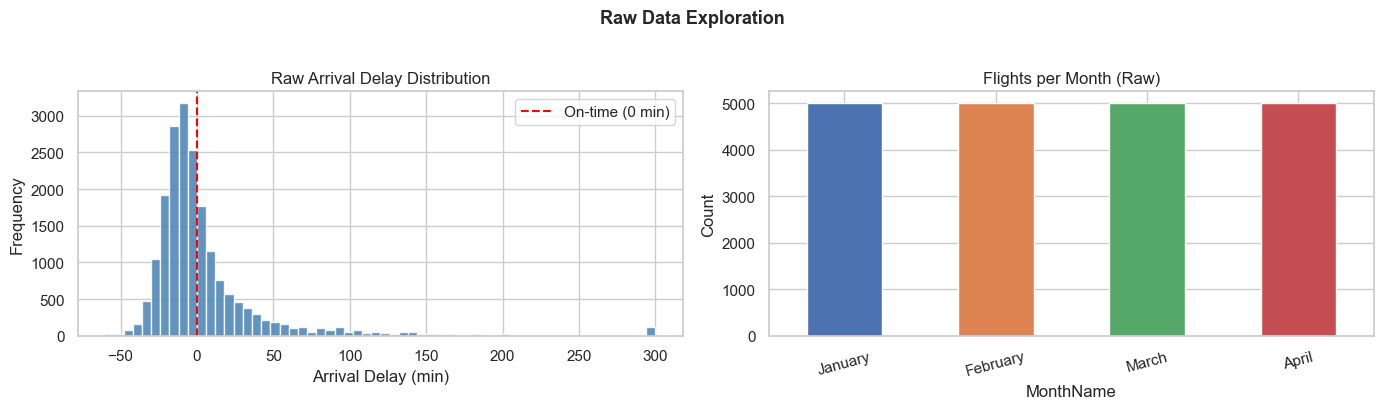

In [13]:
# Quick visual: delay distribution in raw data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['ArrDelay'].dropna().clip(-60, 300), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', label='On-time (0 min)')
axes[0].set_title('Raw Arrival Delay Distribution')
axes[0].set_xlabel('Arrival Delay (min)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df_raw['MonthName'].value_counts().reindex(
    ['January','February','March','April']).plot(kind='bar', ax=axes[1],
    color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('Flights per Month (Raw)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Raw Data Exploration', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 🧹 Step 4: Data Cleaning
Based on exploration, we apply the following cleaning steps:

| Step | Action | Reason |
|---|---|---|
| 1 | Remove cancelled & diverted flights | These have no meaningful delay data |
| 2 | Drop rows with NaN in core columns | `ArrDelay`, `DepDelay`, `AirTime`, `Distance` are essential |
| 3 | Fill delay-cause NaNs with 0 | NaN = no delay from that cause, not truly missing |
| 4 | Remove impossible outliers | Negative airtime / distance or extreme delay values are errors |


In [14]:
print(f"Rows BEFORE cleaning: {len(df_raw):,}")

# Step 1: Remove cancelled and diverted flights
df = df_raw[(df_raw['Cancelled'] == 0) & (df_raw['Diverted'] == 0)].copy()
print(f"After removing cancelled/diverted: {len(df):,} ({len(df_raw)-len(df)} removed)")

# Step 2: Drop rows with NaN in essential columns
essential = ['ArrDelay', 'DepDelay', 'AirTime', 'Distance', 'TaxiOut', 'TaxiIn']
before = len(df)
df.dropna(subset=essential, inplace=True)
print(f"After dropping NaN in essential cols: {len(df):,} ({before-len(df)} removed)")

# Step 3: Fill delay-cause NaN → 0
delay_cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df[delay_cause_cols] = df[delay_cause_cols].fillna(0)
print(f"Filled NaN in delay-cause columns with 0")

# Step 4: Remove outliers
before = len(df)
df = df[(df['AirTime'] > 0) & (df['Distance'] > 0)]
df = df[df['ArrDelay'].between(-120, 600)]
df = df[df['DepDelay'].between(-60, 600)]
print(f"After removing outliers: {len(df):,} ({before-len(df)} removed)")

print(f"\n✅ Final cleaned shape: {df.shape}")
print(f"   Missing values remaining: {df.isnull().sum().sum()} (only in non-essential cols)")


Rows BEFORE cleaning: 20,000
After removing cancelled/diverted: 19,680 (320 removed)
After dropping NaN in essential cols: 19,680 (0 removed)
Filled NaN in delay-cause columns with 0
After removing outliers: 19,648 (32 removed)

✅ Final cleaned shape: (19648, 34)
   Missing values remaining: 19648 (only in non-essential cols)


## ⚙️ Step 5: Feature Engineering
Creating new columns that will be useful for EDA and ML in later notebooks.


In [15]:
# Binary delay label
df['IsDelayed'] = (df['ArrDelay'] > 15).astype(int)

# Categorical delay severity
df['DelayCategory'] = pd.cut(df['ArrDelay'],
    bins=[-120, 0, 15, 60, 600],
    labels=['Early/OnTime', 'Minor Delay', 'Moderate Delay', 'Severe Delay'])

# Aircraft speed (miles per hour)
df['SpeedMph'] = (df['Distance'] / (df['AirTime'] / 60)).round(2)

# Total ground time
df['TotalGround'] = df['TaxiOut'] + df['TaxiIn']

df.reset_index(drop=True, inplace=True)
print("✅ New features added:")
print(f"  IsDelayed       → {df['IsDelayed'].value_counts().to_dict()}")
print(f"  DelayCategory   → {df['DelayCategory'].value_counts().to_dict()}")
print(f"  SpeedMph range  → {df['SpeedMph'].min():.0f} – {df['SpeedMph'].max():.0f} mph")
print(f"  TotalGround mean→ {df['TotalGround'].mean():.1f} min")


✅ New features added:
  IsDelayed       → {0: 15724, 1: 3924}
  DelayCategory   → {'Early/OnTime': 12684, 'Minor Delay': 3040, 'Moderate Delay': 2568, 'Severe Delay': 1356}
  SpeedMph range  → 124 – 639 mph
  TotalGround mean→ 25.9 min


In [16]:
# Post-cleaning summary
print("─── Post-Cleaning Statistical Summary ───")
df[['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'SpeedMph', 'TotalGround']].describe().round(2)


─── Post-Cleaning Statistical Summary ───


,ArrDelay,DepDelay,Distance,AirTime,SpeedMph,TotalGround
count,19648.00,19648.00,19648.00,19648.00,19648.00,19648.00
mean,5.26,10.99,820.49,114.45,405.37,25.90
std,45.32,42.00,576.25,68.98,75.35,12.36
min,-75.00,-25.00,31.00,11.00,124.00,9.00
25%,-16.00,-6.00,403.00,64.00,360.00,18.00
50%,-6.00,-2.00,687.00,99.00,408.46,23.00
75%,9.00,9.00,1061.00,143.00,454.71,30.00
max,576.00,587.00,4817.00,514.00,639.06,202.00


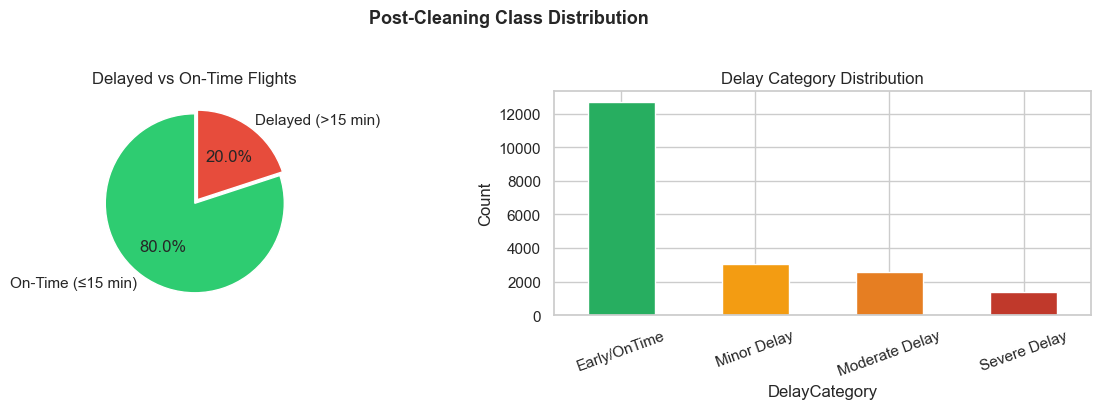


✅ Delayed flights: 3,924 / 19,648 (20.0%)


In [17]:
# Verify class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['On-Time (≤15 min)', 'Delayed (>15 min)']
sizes = df['IsDelayed'].value_counts().values
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Delayed vs On-Time Flights')

df['DelayCategory'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#27ae60','#f39c12','#e67e22','#c0392b'], edgecolor='white')
axes[1].set_title('Delay Category Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Post-Cleaning Class Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\n✅ Delayed flights: {df['IsDelayed'].sum():,} / {len(df):,} ({df['IsDelayed'].mean()*100:.1f}%)")


## 💾 Step 6: Save Cleaned Dataset
We save the cleaned dataset as `flight_cleaned_20k.csv` which will be loaded in **Notebook 2** for EDA and ML.


In [18]:
df.to_csv(r"C:\Users\ASUS\Downloads\DataS_Project\flight_cleaned_20k.csv", index=False)
print(f"✅ Saved: flight_cleaned_20k.csv")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   File ready for Notebook 2 → EDA, Visualization & ML")


✅ Saved: flight_cleaned_20k.csv
   Shape: 19,648 rows × 38 columns
   File ready for Notebook 2 → EDA, Visualization & ML


## ✅ Summary — Notebook 1
| Metric | Value |
|---|---|
| Raw records loaded | 20,000 |
| Records after cleaning | ~19,649 |
| Records removed | ~351 (cancelled, diverted, missing) |
| Features engineered | 4 new columns |
| Final columns | 38 |

➡️ **Next:** Open `Notebook_2_EDA_Visualization_ML.ipynb` for deep analysis, visualizations, and machine learning models.
